In [1]:
import pandas as pd
import umap
import umap.plot
from rich import print

from sklearn.feature_extraction.text import  TfidfVectorizer
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
df = pd.read_csv("/Users/justinvhuang/Desktop/ISYE-CSE-MGT-6748-Group-1/data/postings.csv", index_col=0)

/var/folders/vz/cyjrzm0x74q21sb72nhkdfmr0000gn/T/ipykernel_80804/2523274885.py:1: DtypeWarning: Columns (5,11,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/justinvhuang/Desktop/ISYE-CSE-MGT-6748-Group-1/data/postings.csv", index_col=0)


In [3]:
df['naics_2022_2_name'].nunique()

21

In [4]:
pd.DataFrame(Counter(df['naics2_name']).items()).rename(columns = {0:'NAICS2_NAME', 1: 'Count'}).sort_values(by='Count', ascending=False)

,NAICS2_NAME,Count
3,Unclassified Industry,229656
6,"Professional, Scientific, and Technical Services",136744
17,Health Care and Social Assistance,136080
0,Administrative and Support and Waste Managemen...,134787
2,Manufacturing,99721
4,Retail Trade,87623
12,Finance and Insurance,83659
18,Educational Services,63744
16,Accommodation and Food Services,34591
10,Construction,33941


In [5]:
df_unclassified = df[df['naics2_name'] == 'Unclassified Industry']['body'].reset_index(drop = True)
df_unclassified.to_csv("/Users/justinvhuang/Desktop/ISYE-CSE-MGT-6748-Group-1/data/unclassified_posting_v2.csv")

0         Between $15.00 and\n$20.00\nPer Hour\nPosition...
1         Position range in Sioux Falls, SD Metropolitan...
2         Welder/Heat Transfer\n\n\nJob Order Number\n\t...
3         Welder/Fabricator\nNiagara Power Transformer C...
4         MIG WELDER (Santa Fe Springs) MEDLIN RAMPS 149...
                                ...                        
229651    Position range in Sioux Falls, SD Metropolitan...
229652    Position range in Sioux Falls, SD Metropolitan...
229653    Entry Level Welder\n\nCompany: People First St...
229654    Position range in Sioux Falls, SD Metropolitan...
229655    Position range in East Area\n$37k - $48k\nPer ...
Name: body, Length: 229656, dtype: object

In [6]:
df2 = df[df['naics2_name'] == 'Professional, Scientific, and Technical Services'].reset_index(drop = True)

In [7]:
df2['naics5_name'].unique()

array(['Translation and Interpretation Services',
       'Computer Systems Design and Related Services',
       'Accounting, Tax Preparation, Bookkeeping, and Payroll Services',
       'Management Consulting Services', 'Offices of Lawyers',
       'Engineering Services',
       'All Other Professional, Scientific, and Technical Services',
       'Research and Development in the Physical, Engineering, and Life Sciences',
       'Building Inspection Services',
       'Surveying and Mapping (except Geophysical) Services',
       'Other Services Related to Advertising',
       'Testing Laboratories and Services', 'Other Legal Services',
       'Research and Development in the Social Sciences and Humanities',
       'Other Scientific and Technical Consulting Services',
       'Advertising Material Distribution Services',
       'Architectural Services', 'Interior Design Services',
       'Environmental Consulting Services', 'Photographic Services',
       'Landscape Architectural Services',

In [160]:
#df2.to_csv("/Users/justinvhuang/Desktop/ISYE-CSE-MGT-6748-Group-1/data/professional_scientific_technical_services.csv")

In [8]:
tfidf_vectorizer = TfidfVectorizer(
    min_df=20, 
    max_df=100, 
    stop_words='english', 
    token_pattern=r'\b[a-zA-Z0-9_]+\b',
    lowercase = True
)
tfidf_word_doc_matrix = tfidf_vectorizer.fit_transform(df2.body)

In [9]:
tfidf_word_doc_matrix

<136744x14980 sparse matrix of type '<class 'numpy.float64'>'
	with 659830 stored elements in Compressed Sparse Row format>

In [14]:
category_labels = [df2.naics5_name[x] for x in df2.naics5]
hover_df = pd.DataFrame(category_labels, columns=['category'])

In [15]:
category_labels

['Offices of Lawyers',
 'Offices of Lawyers',
 'Offices of Lawyers',
 'Offices of Lawyers',
 'Offices of Lawyers',
 'Offices of Lawyers',
 'Offices of Lawyers',
 'Offices of Lawyers',
 'Offices of Lawyers',
 'Offices of Lawyers',
 'All Other Professional, Scientific, and Technical Services',
 'Offices of Lawyers',
 'All Other Professional, Scientific, and Technical Services',
 'All Other Professional, Scientific, and Technical Services',
 'Offices of Lawyers',
 'Offices of Lawyers',
 'Offices of Lawyers',
 'Other Legal Services',
 'Offices of Lawyers',
 'Offices of Lawyers',
 'Offices of Lawyers',
 'All Other Professional, Scientific, and Technical Services',
 'All Other Professional, Scientific, and Technical Services',
 'All Other Professional, Scientific, and Technical Services',
 'All Other Professional, Scientific, and Technical Services',
 'Offices of Lawyers',
 'All Other Professional, Scientific, and Technical Services',
 'Offices of Lawyers',
 'All Other Professional, Scientif

In [18]:
tfidf_embedding = umap.UMAP(metric='cosine', n_neighbors = 500).fit(tfidf_word_doc_matrix)

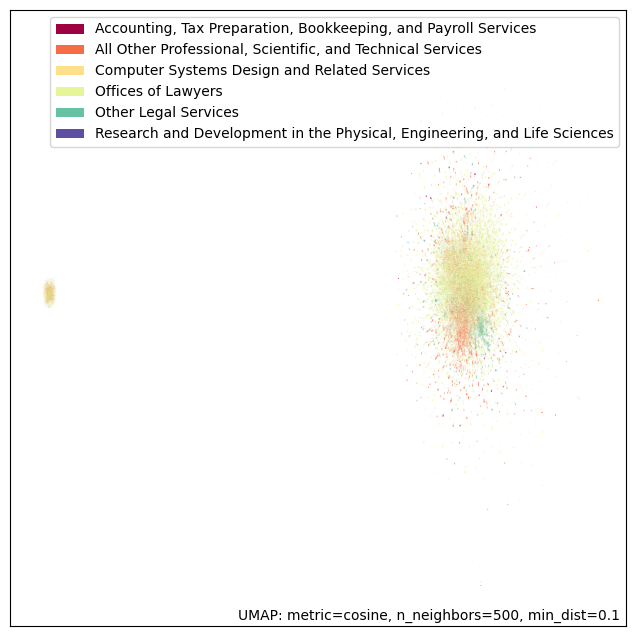

In [19]:
fig = umap.plot.points(tfidf_embedding, labels=hover_df['category'])